/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 30ms/step - accuracy: 0.9574 - loss: 0.1388 - val_accuracy: 0.9865 - val_loss: 0.0429
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 29ms/step - accuracy: 0.9865 - loss: 0.0429 - val_accuracy: 0.9902 - val_loss: 0.0335
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 54s 29ms/step - accuracy: 0.9902 - loss: 0.0302 - val_accuracy: 0.9887 - val_loss: 0.0330
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 54s 29ms/step - accuracy: 0.9929 - loss: 0.0222 - val_accuracy: 0.9882 - val_loss: 0.0356
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 29ms/step - accuracy: 0.9945 - loss: 0.0168 - val_accuracy: 0.9908 - val_loss: 0.0302
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9908 - loss: 0.0302

✅ Test Accuracy: 0.9908000230789185


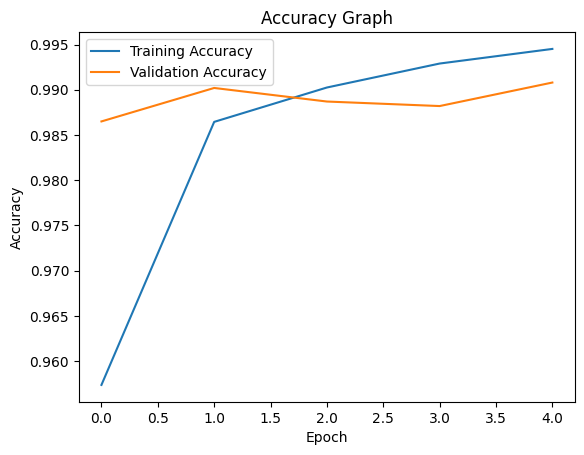

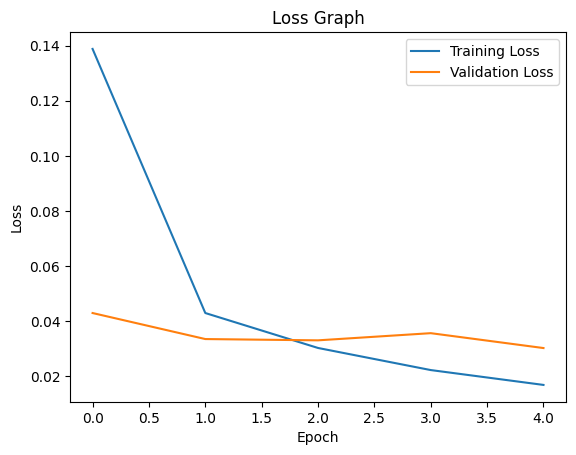

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


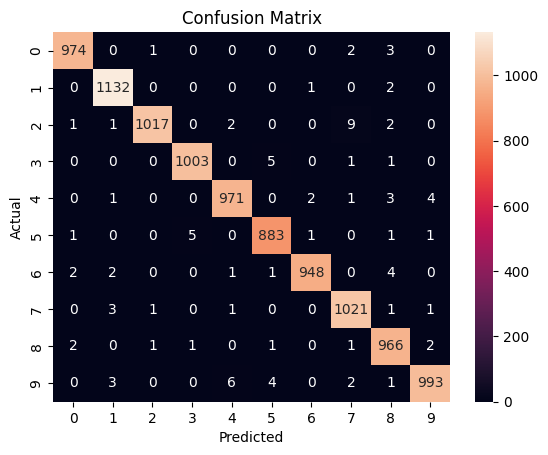

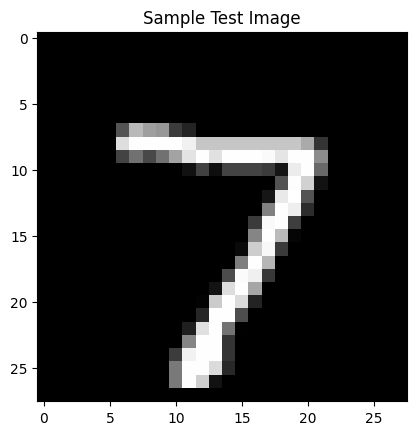

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
🔍 Predicted Digit: 7

📂 Upload your custom digit image (digit.png)


Saving 6.PNG to 6.PNG
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
🧠 Prediction for 6.PNG: 6
💾 Model saved successfully as .keras!

📁 Files in directory: ['.config', 'digit.png', '6.PNG', 'digit_model.keras', 'digit_model.h5', 'digit (1).png', 'sample_data']


In [4]:
# =====================================
# 1. IMPORT LIBRARIES
# =====================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
from PIL import Image
from google.colab import files
import os

# =====================================
# 2. LOAD DATASET
# =====================================
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# =====================================
# 3. PREPROCESSING
# =====================================
x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

# =====================================
# 4. BUILD CNN MODEL
# =====================================
model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# =====================================
# 5. COMPILE MODEL
# =====================================
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# =====================================
# 6. TRAIN MODEL
# =====================================
history = model.fit(
    x_train, y_train,
    epochs=5,
    validation_data=(x_test, y_test)
)

# =====================================
# 7. EVALUATE MODEL
# =====================================
test_loss, test_acc = model.evaluate(x_test, y_test)
print("\n✅ Test Accuracy:", test_acc)

# =====================================
# 8. ACCURACY GRAPH
# =====================================
plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

# =====================================
# 9. LOSS GRAPH
# =====================================
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Graph")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# =====================================
# 10. CONFUSION MATRIX
# =====================================
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# =====================================
# 11. SAMPLE PREDICTION
# =====================================
plt.imshow(x_test[0].reshape(28,28), cmap='gray')
plt.title("Sample Test Image")
plt.show()

prediction = model.predict(x_test[0].reshape(1,28,28,1))
print("🔍 Predicted Digit:", np.argmax(prediction))

# =====================================
# 12. CUSTOM IMAGE UPLOAD + PREDICTION
# =====================================
print("\n📂 Upload your custom digit image (digit.png)")
uploaded = files.upload()

for filename in uploaded.keys():
    img = Image.open(filename).convert('L')
    img = img.resize((28,28))

    img = np.array(img)
    img = 255 - img
    img = img / 255.0
    img = img.reshape(1,28,28,1)

    prediction = model.predict(img)
    print(f"🧠 Prediction for {filename}:", np.argmax(prediction))

# =====================================
# 13. SAVE MODEL (UPDATED FORMAT)
# =====================================
model.save("digit_model.keras")
print("💾 Model saved successfully as .keras!")

# =====================================
# 14. VERIFY FILES
# =====================================
print("\n📁 Files in directory:", os.listdir())